# 🏢 Smart Employee Promotion - Hybrid ML-MCDM Decision Support System
## Kasus 3: Simulasi Pemilihan Kandidat Promosi Karyawan
**Dataset:** HR Analytics Employee Promotion (Kaggle)

Pipeline:
1. Data Phase → Preprocessing & EDA
2. Intelligence Phase → ML Prediction (Random Forest + SMOTE)
3. Normalisasi → Skala 0-1
4. Choice Phase → AHP + TOPSIS Ranking
5. Sensitivity Audit → SHAP Analysis
6. Policy Simulation → What-If Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("All libraries loaded successfully!")

All libraries loaded successfully!


## 1. Data Phase - Akuisisi & Eksplorasi Data

In [3]:
train = pd.read_csv('../materi-5/train.csv')
test = pd.read_csv('../materi-5/test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (54808, 13)
Test shape: (23490, 12)


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [4]:
print("=== Info Dataset ===")
print(train.dtypes)
print("\n=== Missing Values ===")
print(train.isnull().sum())
print("\n=== Statistik Deskriptif ===")
train.describe()

=== Info Dataset ===
employee_id               int64
department                  str
region                      str
education                   str
gender                      str
recruitment_channel         str
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
awards_won?               int64
avg_training_score        int64
is_promoted               int64
dtype: object

=== Missing Values ===
employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

=== Statistik Deskriptif ===


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


=== Distribusi Target (is_promoted) ===
is_promoted
0    50140
1     4668
Name: count, dtype: int64

Persentase Promoted: 8.52%



department: {'Sales & Marketing': 16840, 'Operations': 11348, 'Technology': 7138, 'Procurement': 7138, 'Analytics': 5352, 'Finance': 2536, 'HR': 2418, 'Legal': 1039, 'R&D': 999}

education: {"Bachelor's": 36669, "Master's & above": 14925, 'Below Secondary': 805}

gender: {'m': 38496, 'f': 16312}


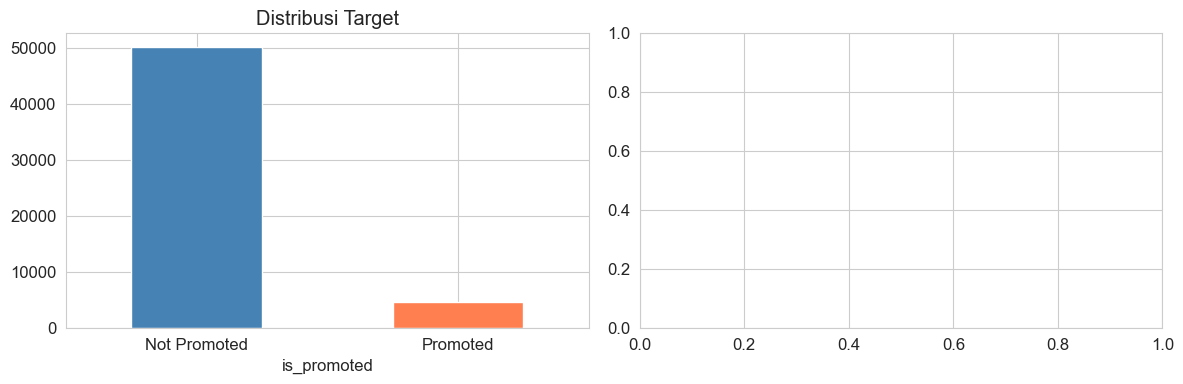

In [5]:
print("=== Distribusi Target (is_promoted) ===")
print(train['is_promoted'].value_counts())
print(f"\nPersentase Promoted: {train['is_promoted'].mean()*100:.2f}%")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['is_promoted'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Distribusi Target'); axes[0].set_xticklabels(['Not Promoted','Promoted'], rotation=0)
for col in ['department','education','gender']:
    print(f"\n{col}: {train[col].value_counts().to_dict()}")
plt.tight_layout(); plt.show()

## 2. Preprocessing - Missing Values & Feature Engineering

In [6]:
# Handle missing values
print("Missing before:")
print(train[['education','previous_year_rating']].isnull().sum())

# Impute education with mode, rating with median
train['education'] = train['education'].fillna(train['education'].mode()[0])
train['previous_year_rating'] = train['previous_year_rating'].fillna(train['previous_year_rating'].median())
test['education'] = test['education'].fillna(test['education'].mode()[0])
test['previous_year_rating'] = test['previous_year_rating'].fillna(test['previous_year_rating'].median())

print("\nMissing after:")
print(train[['education','previous_year_rating']].isnull().sum())

Missing before:
education               2409
previous_year_rating    4124
dtype: int64

Missing after:
education               0
previous_year_rating    0
dtype: int64


In [7]:
# Label Encoding untuk variabel kategorikal
le_dict = {}
cat_cols = ['department', 'region', 'gender', 'recruitment_channel']
df_all = pd.concat([train, test], axis=0, ignore_index=True)

for col in cat_cols:
    le = LabelEncoder()
    le.fit(df_all[col].astype(str))
    train[col + '_enc'] = le.transform(train[col].astype(str))
    test[col + '_enc'] = le.transform(test[col].astype(str))
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Ordinal Encoding untuk education (urutan alami)
edu_map = {'Below Secondary': 1, "Bachelor's": 2, "Master's & above": 3}
train['education_ord'] = train['education'].map(edu_map)
test['education_ord'] = test['education'].map(edu_map)
print(f"\neducation (ordinal): {edu_map}")

# === Feature Engineering - Interaction & Polynomial Features ===
for df in [train, test]:
    # Interaksi rating x training score (fitur paling kuat)
    df['rating_x_training'] = df['previous_year_rating'] * df['avg_training_score']
    # Total score gabungan
    df['total_score'] = df['avg_training_score'] * df['previous_year_rating'] + df['awards_won?'] * 50
    # Pengalaman x rating
    df['experience_rating'] = df['length_of_service'] * df['previous_year_rating']
    # Efisiensi training per tahun kerja
    df['training_per_service'] = df['avg_training_score'] / (df['length_of_service'] + 1)
    # Flag karyawan high performer
    df['high_performer'] = ((df['previous_year_rating'] >= 4) & (df['avg_training_score'] >= 75)).astype(int)
    # Awards x Rating interaction
    df['awards_x_rating'] = df['awards_won?'] * df['previous_year_rating']
    # Rating kuadrat (non-linear)
    df['rating_squared'] = df['previous_year_rating'] ** 2
    # Training score kategori (binning)
    df['training_high'] = (df['avg_training_score'] >= 80).astype(int)
    # Sum of achievements
    df['achievement_score'] = df['awards_won?'] + df['training_high'] + (df['previous_year_rating'] >= 4).astype(int)

print("\nInteraction features created successfully!")

feature_cols = ['department_enc', 'region_enc', 'education_ord', 'gender_enc',
                'recruitment_channel_enc', 'no_of_trainings', 'age',
                'previous_year_rating', 'length_of_service', 'awards_won?',
                'avg_training_score',
                'rating_x_training', 'total_score', 'experience_rating',
                'training_per_service', 'high_performer', 'awards_x_rating',
                'rating_squared', 'training_high', 'achievement_score']
print(f"\nTotal Features ({len(feature_cols)}): {feature_cols}")

department: {'Analytics': np.int64(0), 'Finance': np.int64(1), 'HR': np.int64(2), 'Legal': np.int64(3), 'Operations': np.int64(4), 'Procurement': np.int64(5), 'R&D': np.int64(6), 'Sales & Marketing': np.int64(7), 'Technology': np.int64(8)}
region: {'region_1': np.int64(0), 'region_10': np.int64(1), 'region_11': np.int64(2), 'region_12': np.int64(3), 'region_13': np.int64(4), 'region_14': np.int64(5), 'region_15': np.int64(6), 'region_16': np.int64(7), 'region_17': np.int64(8), 'region_18': np.int64(9), 'region_19': np.int64(10), 'region_2': np.int64(11), 'region_20': np.int64(12), 'region_21': np.int64(13), 'region_22': np.int64(14), 'region_23': np.int64(15), 'region_24': np.int64(16), 'region_25': np.int64(17), 'region_26': np.int64(18), 'region_27': np.int64(19), 'region_28': np.int64(20), 'region_29': np.int64(21), 'region_3': np.int64(22), 'region_30': np.int64(23), 'region_31': np.int64(24), 'region_32': np.int64(25), 'region_33': np.int64(26), 'region_34': np.int64(27), 'region_

## 3. Data Balancing - SMOTE

In [8]:
X = train[feature_cols]
y = train['is_promoted']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val set distribution:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
print("\nNote: Tidak menggunakan SMOTE. Imbalance ditangani oleh class_weight='balanced' pada Random Forest.")
print("Ini mencegah overfitting pada sampel sintetis SMOTE.")

# Langsung gunakan data asli tanpa SMOTE
X_train_sm = X_train
y_train_sm = y_train

Train set distribution: {np.int64(0): np.int64(40112), np.int64(1): np.int64(3734)}
Val set distribution:   {np.int64(0): np.int64(10028), np.int64(1): np.int64(934)}

Note: Tidak menggunakan SMOTE. Imbalance ditangani oleh class_weight='balanced' pada Random Forest.
Ini mencegah overfitting pada sampel sintetis SMOTE.


## 4. Predictive Modeling - Random Forest

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, make_scorer

# === Hyperparameter Tuning dengan RandomizedSearchCV ===
param_dist = {
    'n_estimators': [500, 800, 1000],
    'max_depth': [15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
}

base_model = RandomForestClassifier(
    # class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

f1_scorer = make_scorer(f1_score)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f1_scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("=== Running RandomizedSearchCV (30 iterations, 3-fold CV) ===")
search.fit(X_train_sm, y_train_sm)

print(f"\nBest Parameters: {search.best_params_}")
print(f"Best CV F1-Score: {search.best_score_:.4f}")

model = search.best_estimator_
y_proba = model.predict_proba(X_val)[:, 1]

# === Optimasi Threshold (F1-Score) ===
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
print(f"\nOptimal Threshold: {best_threshold:.4f} (default: 0.50)")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")

y_pred = (y_proba >= best_threshold).astype(int)

print("\n=== Model Evaluation (Optimized) ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_proba):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred, target_names=['Not Promoted','Promoted']))

=== Running RandomizedSearchCV (30 iterations, 3-fold CV) ===
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Best CV F1-Score: 0.4304

Optimal Threshold: 0.3450 (default: 0.50)
Best F1-Score: 0.4690

=== Model Evaluation (Optimized) ===
Accuracy:  0.9250
Precision: 0.5912
Recall:    0.3887
F1-Score:  0.4690
AUC-ROC:   0.7710

=== Classification Report ===
              precision    recall  f1-score   support

Not Promoted       0.94      0.97      0.96     10028
    Promoted       0.59      0.39      0.47       934

    accuracy                           0.93     10962
   macro avg       0.77      0.68      0.71     10962
weighted avg       0.91      0.93      0.92     10962



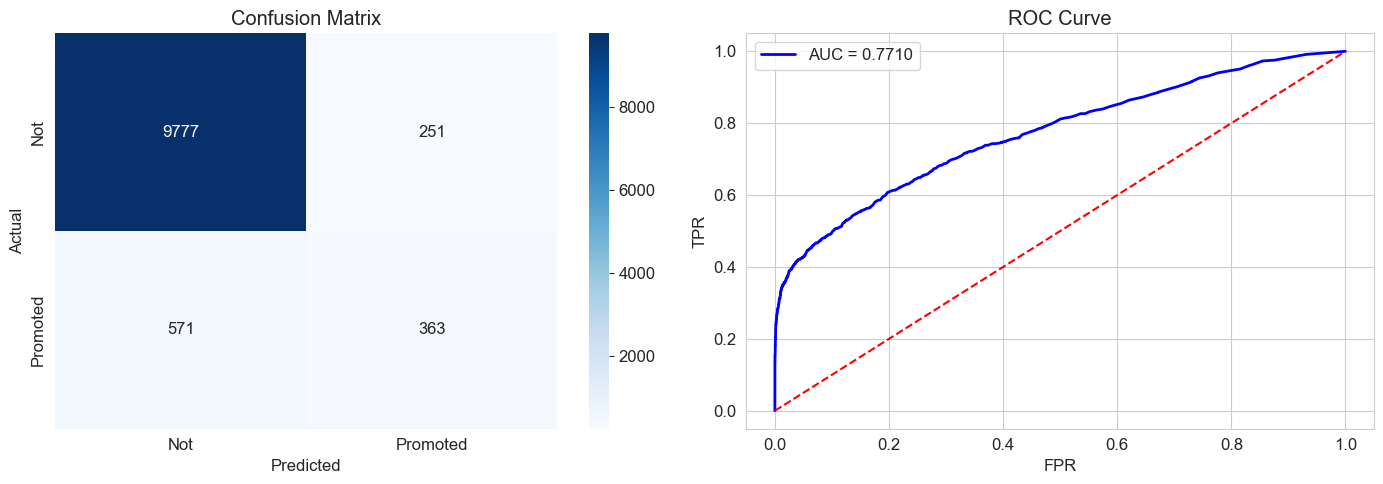

In [10]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not','Promoted'], yticklabels=['Not','Promoted'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc_score(y_val, y_proba):.4f}')
axes[1].plot([0,1],[0,1],'r--'); axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()
plt.tight_layout(); plt.savefig('model_eval.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Sensitivity Audit - SHAP Analysis

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# SHAP Bar Plot
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_val, feature_names=feature_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar)')
plt.tight_layout(); plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. Prediksi Probabilitas Promosi (Test Set)

In [ ]:
test_proba = model.predict_proba(test[feature_cols])[:, 1]
test['promo_probability'] = test_proba
test['predicted_promoted'] = (test_proba >= 0.5).astype(int)
print(f"Jumlah diprediksi promoted: {test['predicted_promoted'].sum()} dari {len(test)}")
test[['employee_id','department','promo_probability','predicted_promoted']].head(10)

## 7. Decision Matrix & MCDM - AHP + TOPSIS
### Membangun Matriks Keputusan
Kriteria: Probabilitas Promosi (ML), Masa Kerja, Awards, Avg Training Score, Previous Year Rating

In [ ]:
# Pilih top 20 kandidat berdasarkan probabilitas promosi untuk demonstrasi SPK
candidates = test.nlargest(20, 'promo_probability').copy()

# Kriteria untuk MCDM
criteria_cols = ['promo_probability', 'length_of_service', 'awards_won?',
                 'avg_training_score', 'previous_year_rating']
criteria_names = ['Prob_Promosi', 'Masa_Kerja', 'Awards', 'Skor_Latih', 'Rating']

decision_matrix = candidates[criteria_cols].copy()
decision_matrix.columns = criteria_names
decision_matrix.index = candidates['employee_id']
print("=== Decision Matrix (Raw) ===")
decision_matrix

### AHP Weighting - Pembobotan Kriteria

In [ ]:
# AHP Pairwise Comparison Matrix (skala Saaty 1-9)
# Urutan: Prob_Promosi, Masa_Kerja, Awards, Skor_Latih, Rating
ahp_matrix = np.array([
    [1,   3,   2,   2,   3],   # Prob_Promosi
    [1/3, 1,   1/2, 1/2, 1],   # Masa_Kerja
    [1/2, 2,   1,   1,   2],   # Awards
    [1/2, 2,   1,   1,   2],   # Skor_Latih
    [1/3, 1,   1/2, 1/2, 1],   # Rating
])

# Hitung bobot AHP (geometric mean method)
geo_mean = np.prod(ahp_matrix, axis=1) ** (1/ahp_matrix.shape[1])
weights = geo_mean / geo_mean.sum()

# Consistency check
col_sum = ahp_matrix.sum(axis=0)
norm_matrix = ahp_matrix / col_sum
priority = norm_matrix.mean(axis=1)
lambda_max = (ahp_matrix @ priority / priority).mean()
CI = (lambda_max - len(weights)) / (len(weights) - 1)
RI = 1.12  # for n=5
CR = CI / RI

print("=== AHP Weights ===")
for n, w in zip(criteria_names, weights):
    print(f"  {n:15s}: {w:.4f}")
print(f"\nConsistency Ratio (CR): {CR:.4f}")
print(f"CR < 0.1? {'YES - Consistent!' if CR < 0.1 else 'NO - Inconsistent!'}")

### TOPSIS Implementation

In [ ]:
def topsis(matrix, weights, benefit_criteria):
    # Step 1: Normalize
    norm = matrix / np.sqrt((matrix**2).sum(axis=0))
    # Step 2: Weighted normalized
    weighted = norm * weights
    # Step 3: Ideal solutions
    ideal_pos = np.where(benefit_criteria, weighted.max(axis=0), weighted.min(axis=0))
    ideal_neg = np.where(benefit_criteria, weighted.min(axis=0), weighted.max(axis=0))
    # Step 4: Distance
    dist_pos = np.sqrt(((weighted - ideal_pos)**2).sum(axis=1))
    dist_neg = np.sqrt(((weighted - ideal_neg)**2).sum(axis=1))
    # Step 5: Closeness coefficient
    score = dist_neg / (dist_pos + dist_neg)
    return score

# All criteria are benefit (higher is better)
benefit = np.array([True, True, True, True, True])
dm_values = decision_matrix.values.astype(float)

topsis_scores = topsis(dm_values, weights, benefit)
decision_matrix['TOPSIS_Score'] = topsis_scores
decision_matrix['Rank'] = decision_matrix['TOPSIS_Score'].rank(ascending=False).astype(int)
decision_matrix_sorted = decision_matrix.sort_values('Rank')

print("=== Ranking Kandidat Promosi (TOPSIS) ===")
decision_matrix_sorted

In [ ]:
# Visualisasi Ranking
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(decision_matrix_sorted)))[::-1]
bars = ax.barh(range(len(decision_matrix_sorted)),
               decision_matrix_sorted['TOPSIS_Score'],
               color=colors)
ax.set_yticks(range(len(decision_matrix_sorted)))
ax.set_yticklabels([f"EMP-{eid}" for eid in decision_matrix_sorted.index])
ax.set_xlabel('TOPSIS Score')
ax.set_title('Ranking Kandidat Promosi (Top 20)')
ax.invert_yaxis()
for i, (v, r) in enumerate(zip(decision_matrix_sorted['TOPSIS_Score'], decision_matrix_sorted['Rank'])):
    ax.text(v + 0.005, i, f'#{r} ({v:.3f})', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('promotion_ranking.png', dpi=150, bbox_inches='tight'); plt.show()

### Tabel Matriks Sebelum & Sesudah Normalisasi

In [ ]:
scaler = MinMaxScaler()
dm_normalized = pd.DataFrame(
    scaler.fit_transform(decision_matrix[criteria_names]),
    columns=[f"{c}_norm" for c in criteria_names],
    index=decision_matrix.index
)

comparison = pd.concat([decision_matrix[criteria_names], dm_normalized], axis=1)
print("=== Perbandingan Sebelum & Sesudah Normalisasi ===")
comparison.head(10)

## 8. What-If Analysis & Policy Simulation
**Skenario:** "Jika seorang karyawan memiliki masa kerja sangat lama namun prediksi performanya (ML) rendah, apakah ia tetap layak masuk urutan teratas promosi?" 

In [ ]:
# Buat 5 kandidat sintetis untuk simulasi
synthetic = pd.DataFrame({
    'Employee': ['Senior_LowPerf', 'Junior_HighPerf', 'Mid_Balanced', 'Senior_HighPerf', 'Junior_LowPerf'],
    'Prob_Promosi': [0.20, 0.90, 0.55, 0.85, 0.15],
    'Masa_Kerja':  [25,   3,    10,   20,   2],
    'Awards':      [0,    1,    1,    1,    0],
    'Skor_Latih':  [45,   88,   65,   90,   40],
    'Rating':      [2.0,  5.0,  3.5,  4.5,  2.0]
}).set_index('Employee')

print("=== Profil Kandidat Sintetis ===")
print(synthetic)

syn_vals = synthetic.values.astype(float)
syn_scores = topsis(syn_vals, weights, benefit)
synthetic['TOPSIS_Score'] = syn_scores
synthetic['Rank'] = synthetic['TOPSIS_Score'].rank(ascending=False).astype(int)
print("\n=== Ranking Baseline ===")
print(synthetic.sort_values('Rank'))

In [ ]:
# What-If: Ubah avg_training_score Senior_LowPerf dari 45 -> 80
scenarios = {}
syn_base = synthetic[criteria_names].copy()

# Scenario 1: Senior improves training score
syn_s1 = syn_base.copy()
syn_s1.loc['Senior_LowPerf', 'Skor_Latih'] = 80
s1_scores = topsis(syn_s1.values.astype(float), weights, benefit)
scenarios['S1: Senior +Training'] = dict(zip(syn_base.index, s1_scores))

# Scenario 2: Junior wins award
syn_s2 = syn_base.copy()
syn_s2.loc['Junior_LowPerf', 'Awards'] = 1
syn_s2.loc['Junior_LowPerf', 'Skor_Latih'] = 75
s2_scores = topsis(syn_s2.values.astype(float), weights, benefit)
scenarios['S2: Junior +Award+Train'] = dict(zip(syn_base.index, s2_scores))

# Scenario 3: Heavier weight on seniority (masa kerja)
weights_senior = np.array([0.25, 0.35, 0.10, 0.15, 0.15])
s3_scores = topsis(syn_base.values.astype(float), weights_senior, benefit)
scenarios['S3: Weight Seniority'] = dict(zip(syn_base.index, s3_scores))

# Compare
baseline = dict(zip(syn_base.index, topsis(syn_base.values.astype(float), weights, benefit)))
result_df = pd.DataFrame({'Baseline': baseline, **scenarios})
result_df = result_df.round(4)
print("=== What-If Comparison ===")
print(result_df)
print("\nKesimpulan: Karyawan senior dengan performa rendah TIDAK otomatis masuk teratas.")
print("Sistem hybrid ML-MCDM memastikan keputusan berbasis multi-kriteria, bukan satu faktor saja.")

In [ ]:
# Visualisasi What-If
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(result_df))
w = 0.2
for i, col in enumerate(result_df.columns):
    ax.bar(x + i*w, result_df[col], w, label=col)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(result_df.index, rotation=15)
ax.set_ylabel('TOPSIS Score')
ax.set_title('What-If Analysis: Perubahan Ranking Berdasarkan Skenario')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(); plt.savefig('what_if_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Smart HR Promotion Dashboard - Simulasi Input Profil Baru

In [ ]:
def predict_and_rank(employee_profiles, model, le_dict, feature_cols, weights, benefit):
    """Simulasi dashboard: input profil -> prediksi -> ranking"""
    df = pd.DataFrame(employee_profiles)
    
    # Encode categorical
    for col in ['department', 'region', 'education', 'gender', 'recruitment_channel']:
        df[col + '_enc'] = le_dict[col].transform(df[col].astype(str))
    
    # Predict probability
    proba = model.predict_proba(df[feature_cols])[:, 1]
    df['promo_probability'] = proba
    
    # Build decision matrix
    dm = df[['promo_probability','length_of_service','awards_won?',
             'avg_training_score','previous_year_rating']].values.astype(float)
    scores = topsis(dm, weights, benefit)
    df['TOPSIS_Score'] = scores
    df['Rank'] = pd.Series(scores).rank(ascending=False).astype(int).values
    
    return df.sort_values('Rank')

# 5 kandidat uji dengan profil bervariasi
test_candidates = [
    {'name':'Andi (Muda Berprestasi)','department':'Sales & Marketing','region':'region_7',
     'education':"Master's & above",'gender':'m','recruitment_channel':'sourcing',
     'no_of_trainings':3,'age':28,'previous_year_rating':5.0,
     'length_of_service':3,'awards_won?':1,'avg_training_score':92},
    {'name':'Budi (Senior Rata-rata)','department':'Operations','region':'region_2',
     'education':"Bachelor's",'gender':'m','recruitment_channel':'other',
     'no_of_trainings':1,'age':45,'previous_year_rating':3.0,
     'length_of_service':18,'awards_won?':0,'avg_training_score':55},
    {'name':'Citra (Mid KPI Tinggi)','department':'Technology','region':'region_22',
     'education':"Master's & above",'gender':'f','recruitment_channel':'sourcing',
     'no_of_trainings':2,'age':35,'previous_year_rating':4.0,
     'length_of_service':8,'awards_won?':1,'avg_training_score':78},
    {'name':'Dewi (Junior Potensial)','department':'Analytics','region':'region_13',
     'education':"Bachelor's",'gender':'f','recruitment_channel':'sourcing',
     'no_of_trainings':4,'age':26,'previous_year_rating':4.0,
     'length_of_service':2,'awards_won?':0,'avg_training_score':85},
    {'name':'Eko (Senior Berpengalaman)','department':'HR','region':'region_4',
     'education':"Bachelor's",'gender':'m','recruitment_channel':'other',
     'no_of_trainings':1,'age':50,'previous_year_rating':3.0,
     'length_of_service':22,'awards_won?':1,'avg_training_score':60},
]

result = predict_and_rank(test_candidates, model, le_dict, feature_cols, weights, benefit)
print("=== Smart HR Promotion Dashboard ===")
print(result[['name','promo_probability','length_of_service','awards_won?',
              'avg_training_score','TOPSIS_Score','Rank']].to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
res = result.sort_values('Rank')
colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
bars = ax.barh(range(len(res)), res['TOPSIS_Score'], color=colors)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['name'])
ax.set_xlabel('TOPSIS Priority Score')
ax.set_title('Final Promotion Ranking - Smart HR Dashboard')
ax.invert_yaxis()
for i, (v, r) in enumerate(zip(res['TOPSIS_Score'], res['Rank'])):
    ax.text(v+0.005, i, f'Rank #{r} | Prob: {res.iloc[i]["promo_probability"]:.1%}', va='center')
plt.tight_layout(); plt.savefig('final_ranking.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Export Hasil

In [ ]:
decision_matrix_sorted.to_csv('decision_matrix_result.csv')
result.to_csv('dashboard_simulation_result.csv', index=False)
print("Files exported:")
print("  - decision_matrix_result.csv")
print("  - dashboard_simulation_result.csv")
print("  - model_eval.png, shap_summary.png, shap_bar.png")
print("  - promotion_ranking.png, what_if_analysis.png, final_ranking.png")
print("\n✅ Notebook selesai!")

In [ ]:
import joblib
import os

# Menyimpan model dan objek penting lainnya untuk Streamlit
pipeline_objects = {
    'model': model,
    'le_dict': le_dict,
    'feature_cols': feature_cols,
    'weights': weights,
    'benefit': benefit,
    'criteria_names': criteria_names
}

joblib.dump(pipeline_objects, 'hr_promotion_pipeline.pkl')
print('Model dan pipeline objects berhasil disimpan ke hr_promotion_pipeline.pkl!')